<a href="https://colab.research.google.com/github/Claytonbernardodasilva/Analise-de-Linearidade-com-Python/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

# O caminho exato que você encontrou:
caminho_arquivo = '/P1LED GA4.xlsx'

# Lendo o arquivo Excel (note que mudamos para read_excel)
df = pd.read_excel(caminho_arquivo)

# Mostrando as 5 primeiras linhas da nossa tabela
df.head()

,date,sessionSourceMedium,sessionCampaignName,sessionGoogleAdsCampaignName,sessionGoogleAdsAdGroupName,sessionGoogleAdsCreativeId,sessionGoogleAdsCampaignId,sessionGoogleAdsAdGroupId,sessionGoogleAdsCustomerId,sessions,activeUsers,newUsers,engagedSessions,engagementRate,averageSessionDuration,conversions
0,20260504,ig / social,(referral),(not set),(not set),(not set),(not set),(not set),(not set),3961,3902,3903,1718,0.433729,41.611940,0
1,20260504,google / organic,(organic),(not set),(not set),(not set),(not set),(not set),(not set),700,626,617,458,0.654286,114.713799,0
2,20260505,ig / social,(referral),(not set),(not set),(not set),(not set),(not set),(not set),637,621,617,323,0.507064,47.123088,0
3,20260504,google / cpc,blm-search-fundo-venda-por-grupos,blm-search-fundo-venda-por-grupos,35-65-brasil-perene-geral-institucional,732424770199,22211402058,172631700937,2863818062,464,394,395,278,0.599138,89.330459,0
4,20260504,(direct) / (none),(direct),(not set),(not set),(not set),(not set),(not set),(not set),361,335,333,194,0.537396,67.354257,0


In [8]:
# 1. Transformar a coluna 'date' em um formato de calendário que o Python entende
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')

# 2. Vamos agrupar os dados pela Origem/Meio para ver quem traz mais resultado
resumo_canais = df.groupby('sessionSourceMedium').agg(
    sessoes=('sessions', 'sum'),
    conversoes=('conversions', 'sum'),
    taxa_engajamento_media=('engagementRate', 'mean')
).reset_index()

# 3. Ordenar para ver quem trouxe mais sessões no topo
resumo_canais = resumo_canais.sort_values(by='sessoes', ascending=False)

# Mostrar o Top 10 canais
resumo_canais.head(10)

,sessionSourceMedium,sessoes,conversoes,taxa_engajamento_media
27,google / cpc,18704,0,0.596325
28,google / organic,10006,0,0.576231
37,ig / social,7603,0,0.533408
1,(direct) / (none),4799,0,0.519397
0,(data not available),347,0,0.845389
51,meta_ads_ig / 120242151360200590,339,0,0.338468
42,l.wl.co / referral,214,0,0.505843
15,chatgpt.com / (not set),158,0,0.639773
12,bing / organic,135,0,0.562865
24,facebook.com / referral,134,0,0.879777


In [9]:
# 1. Vamos pegar apenas as linhas onde a origem é Google Ads
df_ads = df[df['sessionSourceMedium'] == 'google / cpc'].copy()

# 2. Agrupar por Campanha e Grupo de Anúncios
resumo_campanhas = df_ads.groupby(['sessionGoogleAdsCampaignName', 'sessionGoogleAdsAdGroupName']).agg(
    sessoes=('sessions', 'sum'),
    taxa_engajamento=('engagementRate', 'mean'),
    duracao_media_segundos=('averageSessionDuration', 'mean')
).reset_index()

# 3. Filtrar grupos com pelo menos 50 sessões (para não avaliarmos anomalias estatísticas)
resumo_campanhas = resumo_campanhas[resumo_campanhas['sessoes'] > 50]

# 4. Ordenar da MAIOR taxa de engajamento para a menor
resumo_campanhas = resumo_campanhas.sort_values(by='taxa_engajamento', ascending=False)

# Mostrar o Top 10 campanhas e grupos
resumo_campanhas.head(10)

,sessionGoogleAdsCampaignName,sessionGoogleAdsAdGroupName,sessoes,taxa_engajamento,duracao_media_segundos
26,blm-search-topo-pf-concorrencia,35-65-brasil-perene-geral,130,0.825926,111.587780
24,blm-search-fundo-venda-por-grupos,35-65-brasil-perene-geral-tipos-aplicacoes-pai...,1731,0.714879,185.781295
21,blm-search-fundo-venda-por-grupos,35-65-brasil-perene-geral-institucional,4336,0.690887,147.622647
13,blm-search-fundo-pq-aluguel-por-grupo,35-65-sp-perene-geral,444,0.674331,64.665892
20,blm-search-fundo-venda-por-grupos,35-65-brasil-perene-geral-igrejas,328,0.669275,98.981027
22,blm-search-fundo-venda-por-grupos,35-65-brasil-perene-geral-paineis-teloes-propa...,1626,0.667061,142.671672
4,[ROI] [KC] [PMAX],(not set),176,0.648505,250.304872
14,blm-search-fundo-pq-aluguel-por-grupo,35-65-sp-sazonal-copa,188,0.647484,54.995768
23,blm-search-fundo-venda-por-grupos,35-65-brasil-perene-geral-teloes-led,1311,0.627599,108.429037
15,blm-search-fundo-pq-venda-sazonal,35-65-brasil-sazonal-copa,873,0.617869,69.679937


In [11]:
# 1. Isolar apenas a campanha que você descobriu
nome_da_campanha = 'blm-search-topo-pf-concorrencia'
df_campanha = df_ads[df_ads['sessionGoogleAdsCampaignName'] == nome_da_campanha].copy()

# 2. Agrupar pelos Grupos de Anúncio (Ad Groups) dessa campanha
resumo_adgroups = df_campanha.groupby('sessionGoogleAdsAdGroupName').agg(
    sessoes=('sessions', 'sum'),
    taxa_engajamento=('engagementRate', 'mean'),
    duracao_media_segundos=('averageSessionDuration', 'mean')
).reset_index()

# 3. Vamos criar uma nova métrica para o nosso modelo: "Tempo Total Retido" (Sessões * Duração Média)
# Isso mostra o verdadeiro peso do Ad Group
resumo_adgroups['tempo_total_retido_segundos'] = resumo_adgroups['sessoes'] * resumo_adgroups['duracao_media_segundos']

# 4. Ordenar pelos Ad Groups que mais retêm a atenção das pessoas
resumo_adgroups = resumo_adgroups.sort_values(by='tempo_total_retido_segundos', ascending=False)

# Mostrar os resultados
resumo_adgroups.head(10)

,sessionGoogleAdsAdGroupName,sessoes,taxa_engajamento,duracao_media_segundos,tempo_total_retido_segundos
0,35-65-brasil-perene-geral,130,0.825926,111.58778,14506.41134


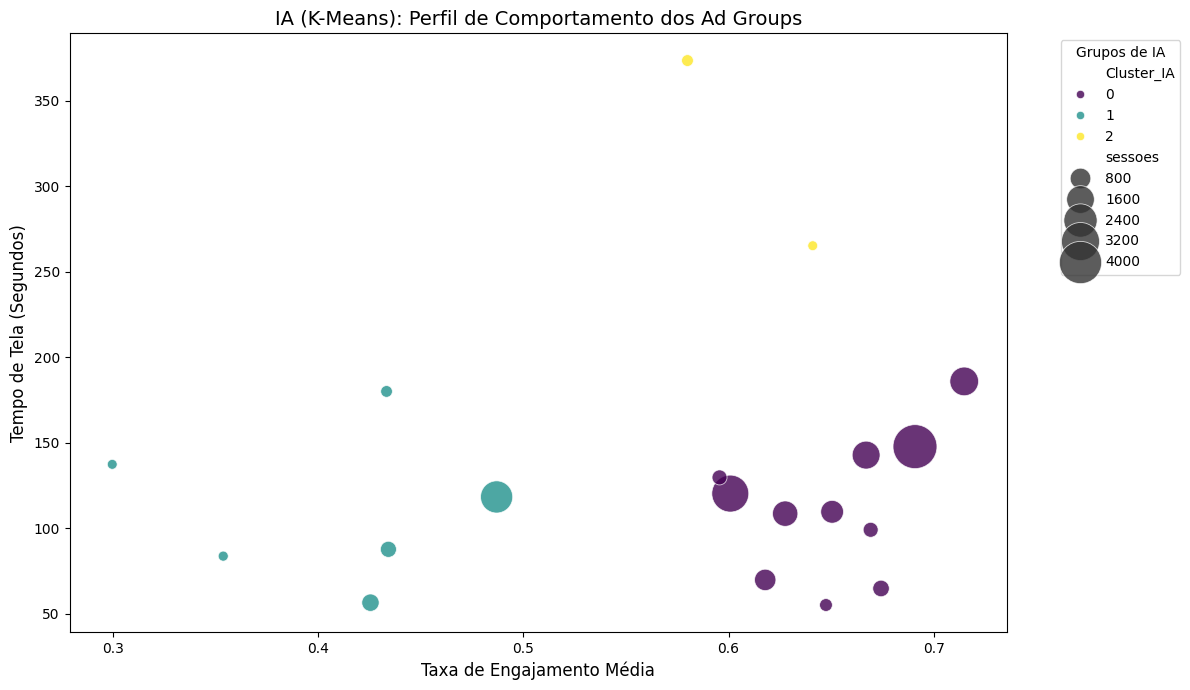

,sessionGoogleAdsAdGroupName,sessoes,taxa_engajamento,duracao_media,Cluster_IA
7,35-65-brasil-perene-geral-institucional,4336,0.690887,147.622647,0
5,35-65-brasil-perene-geral-compra-venda,3005,0.600844,120.163387,0
11,35-65-brasil-perene-geral_painel_de_led,2232,0.486922,118.198453,1
10,35-65-brasil-perene-geral-tipos-aplicacoes-pai...,1731,0.714879,185.781295,0
8,35-65-brasil-perene-geral-paineis-teloes-propa...,1626,0.667061,142.671672,0
9,35-65-brasil-perene-geral-teloes-led,1311,0.627599,108.429037,0
4,35-65-brasil-perene-geral,1018,0.650484,109.505961,0
14,35-65-brasil-sazonal-copa,873,0.617869,69.679937,0
2,00_18-60_sp_awareness_copa,510,0.425424,56.362802,1
15,35-65-sp-perene-geral,444,0.674331,64.665892,0


In [12]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

# 1. Pegar TODOS os Ad Groups do Google Ads
dados_ml = df_ads.groupby('sessionGoogleAdsAdGroupName').agg(
    sessoes=('sessions', 'sum'),
    taxa_engajamento=('engagementRate', 'mean'),
    duracao_media=('averageSessionDuration', 'mean')
).reset_index()

# 2. Filtrar grupos com pouquíssimo tráfego para não confundir a IA (> 20 sessões)
dados_ml = dados_ml[dados_ml['sessoes'] > 20]

# 3. Preparar as features para a IA (Focar na Qualidade)
X = dados_ml[['taxa_engajamento', 'duracao_media']]

# Padronizar os dados (necessário para a IA não confundir % com segundos)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Treinar o modelo K-Means (Vamos pedir para achar 3 grupos/clusters)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
dados_ml['Cluster_IA'] = kmeans.fit_predict(X_scaled)

# 5. Criar um gráfico visual dos Clusters
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=dados_ml,
    x='taxa_engajamento',
    y='duracao_media',
    size='sessoes',
    hue='Cluster_IA', # Pinta cada bolinha com a cor do seu Cluster
    palette='viridis',
    sizes=(50, 1000),
    alpha=0.8
)

plt.title('IA (K-Means): Perfil de Comportamento dos Ad Groups', fontsize=14)
plt.xlabel('Taxa de Engajamento Média', fontsize=12)
plt.ylabel('Tempo de Tela (Segundos)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Grupos de IA")
plt.tight_layout()
plt.show()

# Mostrar a tabela com os top 10 maiores grupos e seus respectivos Clusters
display(dados_ml.sort_values(by='sessoes', ascending=False).head(10))

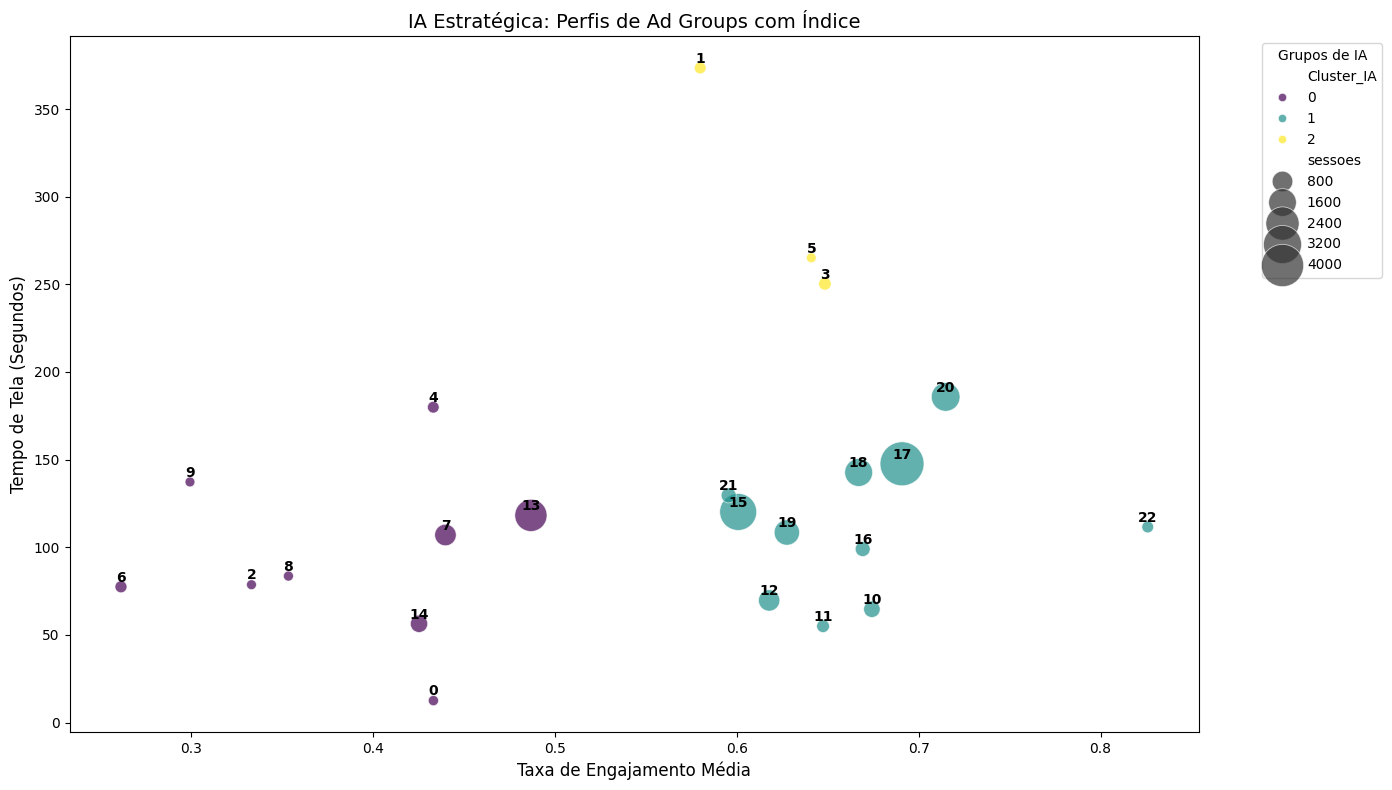


✅ SUCESSO! A tabela completa foi salva no arquivo: /content/Analise_AdGroups_IA.xlsx
--- Tabela Resumo (Cruzando o Índice do Gráfico com a Campanha) ---


,sessionGoogleAdsCampaignName,sessionGoogleAdsAdGroupName,sessoes,taxa_engajamento,duracao_media,conversoes_estimadas_2pct,Cluster_IA
0,(not set),(not set),51,0.433333,12.539207,1,0
1,[ROI] [BC] [SEARCH] [INSITUCIONAL],(YP) Institucional P1LED,130,0.579968,373.430949,2,2
2,[ROI] [BC] [SEARCH] [PAINEL],(not set),34,0.333333,78.655730,0,0
3,[ROI] [KC] [PMAX],(not set),176,0.648505,250.304872,3,2
4,[ROI] [LEADS] [YOUTUBE] [APRESENTAÇÃO P1LED],[BR] [PUB. FRIO] [30+] [RENDA ALTA] [PAINÉIS D...,125,0.433259,179.902908,2,0
5,[ROI] [LEADS] [YOUTUBE] [APRESENTAÇÃO P1LED],[BR] [PUB. FRIO] [30+] [RENDA ALTA] [PAINÉIS D...,31,0.641026,265.131341,0,2
6,blm-demandgen-topo-pf-venda,(not set),141,0.261616,77.463185,2,0
7,blm-demandgen-topo-pf-venda,35-65-brasil-perene-geral,888,0.439953,107.007778,17,0
8,blm-search-fundo-pq-aluguel-por-grupo,35-65-brasil-perene-igrejas-aluguel,40,0.353646,83.577836,0,0
9,blm-search-fundo-pq-aluguel-por-grupo,35-65-brasil-perene-paineis-teloes-propaganda-...,31,0.299534,137.256140,0,0


In [13]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

# 1. Agrupar os dados garantindo que temos a Campanha E o Grupo de Anúncios
dados_ml = df_ads.groupby(['sessionGoogleAdsCampaignName', 'sessionGoogleAdsAdGroupName']).agg(
    sessoes=('sessions', 'sum'),
    taxa_engajamento=('engagementRate', 'mean'),
    duracao_media=('averageSessionDuration', 'mean')
).reset_index()

# 2. Filtrar grupos com tráfego relevante e resetar o índice (para bater com o número do gráfico)
dados_ml = dados_ml[dados_ml['sessoes'] > 20].reset_index(drop=True)

# 3. Aplicar a sua premissa de negócio: Conversão Estimada de 2%
dados_ml['conversoes_estimadas_2pct'] = (dados_ml['sessoes'] * 0.02).astype(int)

# 4. Refazer a IA (K-Means)
X = dados_ml[['taxa_engajamento', 'duracao_media']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
dados_ml['Cluster_IA'] = kmeans.fit_predict(X_scaled)

# 5. Criar o Gráfico com os Índices
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=dados_ml,
    x='taxa_engajamento',
    y='duracao_media',
    size='sessoes',
    hue='Cluster_IA',
    palette='viridis',
    sizes=(50, 1000),
    alpha=0.7
)

# A MÁGICA AQUI: Colocar o número do índice em cima de cada bolha
for i in range(dados_ml.shape[0]):
    plt.text(
        dados_ml['taxa_engajamento'].iloc[i],
        dados_ml['duracao_media'].iloc[i] + 3, # Um leve empurrãozinho para cima para não ficar oculto pela bolha
        str(i), # O número que vai aparecer
        horizontalalignment='center',
        size=10,
        color='black',
        weight='bold'
    )

plt.title('IA Estratégica: Perfis de Ad Groups com Índice', fontsize=14)
plt.xlabel('Taxa de Engajamento Média', fontsize=12)
plt.ylabel('Tempo de Tela (Segundos)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Grupos de IA")
plt.tight_layout()
plt.show()

# 6. Salvar e Exportar para Excel!
nome_arquivo = '/content/Analise_AdGroups_IA.xlsx'
dados_ml.to_excel(nome_arquivo, index=True)

print(f"\n✅ SUCESSO! A tabela completa foi salva no arquivo: {nome_arquivo}")
print("--- Tabela Resumo (Cruzando o Índice do Gráfico com a Campanha) ---")
# Mostramos as primeiras 15 linhas para você poder cruzar com o gráfico
display(dados_ml.head(15))

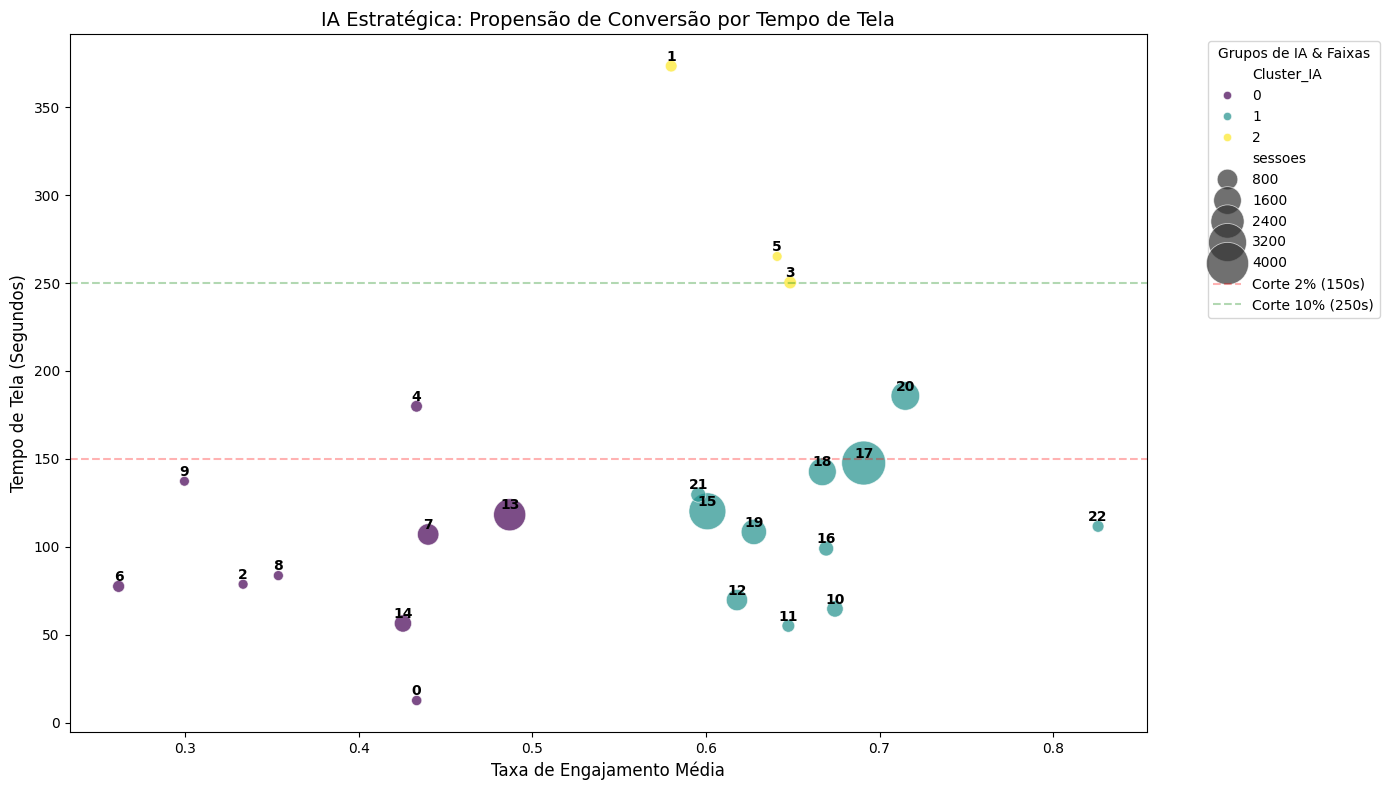


✅ SUCESSO! A tabela completa foi salva no arquivo: /content/Analise_AdGroups_IA_Estrategico.xlsx
--- Tabela Resumo: Lista Completa Sem Limites ---


,sessionGoogleAdsCampaignName,sessionGoogleAdsAdGroupName,sessoes,taxa_engajamento,duracao_media,conversoes_estimadas_estrategicas,Cluster_IA
0,(not set),(not set),51,0.433333,12.539207,1,0
1,[ROI] [BC] [SEARCH] [INSITUCIONAL],(YP) Institucional P1LED,130,0.579968,373.430949,65,2
2,[ROI] [BC] [SEARCH] [PAINEL],(not set),34,0.333333,78.655730,0,0
3,[ROI] [KC] [PMAX],(not set),176,0.648505,250.304872,88,2
4,[ROI] [LEADS] [YOUTUBE] [APRESENTAÇÃO P1LED],[BR] [PUB. FRIO] [30+] [RENDA ALTA] [PAINÉIS D...,125,0.433259,179.902908,12,0
5,[ROI] [LEADS] [YOUTUBE] [APRESENTAÇÃO P1LED],[BR] [PUB. FRIO] [30+] [RENDA ALTA] [PAINÉIS D...,31,0.641026,265.131341,15,2
6,blm-demandgen-topo-pf-venda,(not set),141,0.261616,77.463185,2,0
7,blm-demandgen-topo-pf-venda,35-65-brasil-perene-geral,888,0.439953,107.007778,17,0
8,blm-search-fundo-pq-aluguel-por-grupo,35-65-brasil-perene-igrejas-aluguel,40,0.353646,83.577836,0,0
9,blm-search-fundo-pq-aluguel-por-grupo,35-65-brasil-perene-paineis-teloes-propaganda-...,31,0.299534,137.256140,0,0


In [14]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

# 1. Agrupar os dados garantindo que temos a Campanha E o Grupo de Anúncios
dados_ml = df_ads.groupby(['sessionGoogleAdsCampaignName', 'sessionGoogleAdsAdGroupName']).agg(
    sessoes=('sessions', 'sum'),
    taxa_engajamento=('engagementRate', 'mean'),
    duracao_media=('averageSessionDuration', 'mean')
).reset_index()

# 2. Filtrar grupos com tráfego relevante e resetar o índice
dados_ml = dados_ml[dados_ml['sessoes'] > 20].reset_index(drop=True)

# 3. A SUA LÓGICA DE NEGÓCIO: Conversão Escalonada (High-Ticket)
def calcular_conversao_estrategica(linha):
    tempo = linha['duracao_media']
    sessoes = linha['sessoes']

    if tempo <= 150:
        return int(sessoes * 0.02)   # 2% para curiosos (até 150s)
    elif 150 < tempo <= 250:
        return int(sessoes * 0.10)   # 10% para interessados (151s a 250s)
    else:
        return int(sessoes * 0.50)   # 50% para alto engajamento (acima de 250s)

# Aplicar a regra linha por linha
dados_ml['conversoes_estimadas_estrategicas'] = dados_ml.apply(calcular_conversao_estrategica, axis=1)

# 4. Refazer a IA (K-Means)
X = dados_ml[['taxa_engajamento', 'duracao_media']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
dados_ml['Cluster_IA'] = kmeans.fit_predict(X_scaled)

# 5. Criar o Gráfico com os Índices
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=dados_ml,
    x='taxa_engajamento',
    y='duracao_media',
    size='sessoes',
    hue='Cluster_IA',
    palette='viridis',
    sizes=(50, 1000),
    alpha=0.7
)

for i in range(dados_ml.shape[0]):
    plt.text(
        dados_ml['taxa_engajamento'].iloc[i],
        dados_ml['duracao_media'].iloc[i] + 3,
        str(i),
        horizontalalignment='center',
        size=10,
        color='black',
        weight='bold'
    )

# Adicionar linhas de corte visuais para as suas faixas de tempo!
plt.axhline(y=150, color='red', linestyle='--', alpha=0.3, label='Corte 2% (150s)')
plt.axhline(y=250, color='green', linestyle='--', alpha=0.3, label='Corte 10% (250s)')

plt.title('IA Estratégica: Propensão de Conversão por Tempo de Tela', fontsize=14)
plt.xlabel('Taxa de Engajamento Média', fontsize=12)
plt.ylabel('Tempo de Tela (Segundos)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Grupos de IA & Faixas")
plt.tight_layout()
plt.show()

# 6. Salvar e Exportar para Excel
nome_arquivo = '/content/Analise_AdGroups_IA_Estrategico.xlsx'
dados_ml.to_excel(nome_arquivo, index=True)

print(f"\n✅ SUCESSO! A tabela completa foi salva no arquivo: {nome_arquivo}")
print("--- Tabela Resumo: Lista Completa Sem Limites ---")

# Tirar o limite de exibição do Pandas temporariamente para mostrar TUDO
pd.set_option('display.max_rows', None)
display(dados_ml)
pd.reset_option('display.max_rows') # Devolver ao normal para manter o Colab rápido

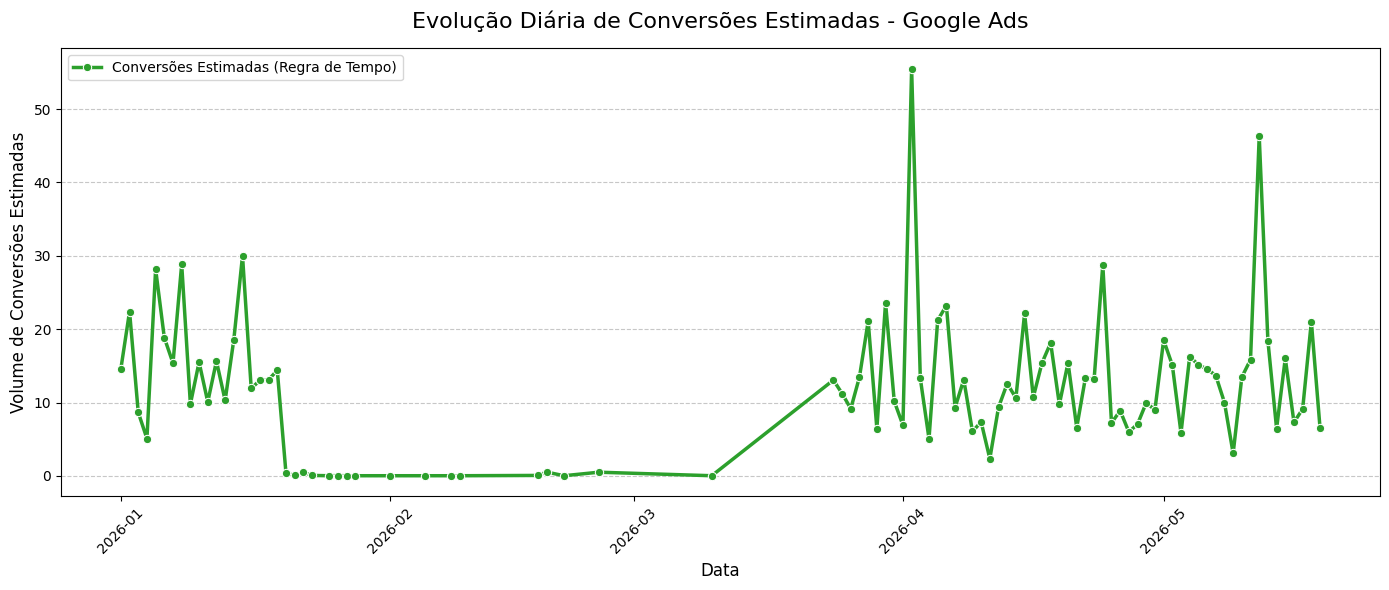


--- Top 5 Dias com Maior Volume de Conversão Estimada ---


,date,total_conversoes,total_sessoes
45,2026-04-02,55.50,223
85,2026-05-12,46.30,339
14,2026-01-15,30.00,184
7,2026-01-08,28.86,179
67,2026-04-24,28.76,214


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Garantir que a data está no formato correto de calendário
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')

# 2. Pegar apenas o tráfego do Google Ads
df_ads = df[df['sessionSourceMedium'] == 'google / cpc'].copy()

# 3. Agrupar os dados por DATA e por GRUPO DE ANÚNCIO
df_diario = df_ads.groupby(['date', 'sessionGoogleAdsAdGroupName']).agg(
    sessoes=('sessions', 'sum'),
    duracao_media=('averageSessionDuration', 'mean')
).reset_index()

# 4. A SUA LÓGICA DE NEGÓCIO (Aplicada dia a dia)
def calcular_conversao_estrategica(linha):
    tempo = linha['duracao_media']
    sessoes = linha['sessoes']

    if tempo <= 150:
        return sessoes * 0.02   # 2% para curiosos
    elif 150 < tempo <= 250:
        return sessoes * 0.10   # 10% para interessados
    else:
        return sessoes * 0.50   # 50% para alta intenção

df_diario['conversoes_estimadas'] = df_diario.apply(calcular_conversao_estrategica, axis=1)

# 5. Somar todas as conversões estimadas por DIA para fazer a linha do tempo
tendencia_diaria = df_diario.groupby('date').agg(
    total_conversoes=('conversoes_estimadas', 'sum'),
    total_sessoes=('sessoes', 'sum')
).reset_index()

# 6. Criar o Gráfico de Linha (Timeline)
plt.figure(figsize=(14, 6))

# Linha das Conversões Estimadas
sns.lineplot(
    data=tendencia_diaria,
    x='date',
    y='total_conversoes',
    marker='o',
    linewidth=2.5,
    color='#2ca02c', # Cor verde para conversões
    label='Conversões Estimadas (Regra de Tempo)'
)

# Configurações visuais do gráfico
plt.title('Evolução Diária de Conversões Estimadas - Google Ads', fontsize=16, pad=15)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Volume de Conversões Estimadas', fontsize=12)
plt.xticks(rotation=45) # Inclinar as datas para não ficarem sobrepostas
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.tight_layout()

# Mostrar o gráfico
plt.show()

# Opcional: Mostrar também a tabelinha dos dias mais fortes
print("\n--- Top 5 Dias com Maior Volume de Conversão Estimada ---")
display(tendencia_diaria.sort_values(by='total_conversoes', ascending=False).head(5))

In [16]:
from scipy import stats
import pandas as pd

# 1. Vamos dividir o dataset do gráfico em dois períodos (ex: Dia 04 ao 11 vs Dia 12 ao 19)
# Assumindo que sua tabela se chama 'tendencia_diaria' (do script anterior)
meio_do_caminho = tendencia_diaria['date'].median()

periodo_fome = tendencia_diaria[tendencia_diaria['date'] <= meio_do_caminho]['total_conversoes']
periodo_fartura = tendencia_diaria[tendencia_diaria['date'] > meio_do_caminho]['total_conversoes']

# 2. Aplicar o Teste T para amostras independentes
t_stat, p_value = stats.ttest_ind(periodo_fome, periodo_fartura, equal_var=False)

print("--- Teste de Hipótese: Primeira Quinzena vs Segunda Quinzena ---")
print(f"Média Período 1: {periodo_fome.mean():.2f} conversões estimadas")
print(f"Média Período 2: {periodo_fartura.mean():.2f} conversões estimadas")
print(f"\nEstatística T: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

# 3. O Veredito
if p_value < 0.05:
    print("\n✅ Veredito: REJEITAMOS H0! A diferença é estatisticamente significativa. O padrão de conversão mudou de verdade.")
else:
    print("\n❌ Veredito: FALHAMOS EM REJEITAR H0. A diferença não é estatisticamente significativa. A oscilação pode ser só barulho/acaso (o povo sempre passou um pouco de fome).")

--- Teste de Hipótese: Primeira Quinzena vs Segunda Quinzena ---
Média Período 1: 10.43 conversões estimadas
Média Período 2: 12.92 conversões estimadas

Estatística T: -1.2618
P-Value: 0.2106

❌ Veredito: FALHAMOS EM REJEITAR H0. A diferença não é estatisticamente significativa. A oscilação pode ser só barulho/acaso (o povo sempre passou um pouco de fome).


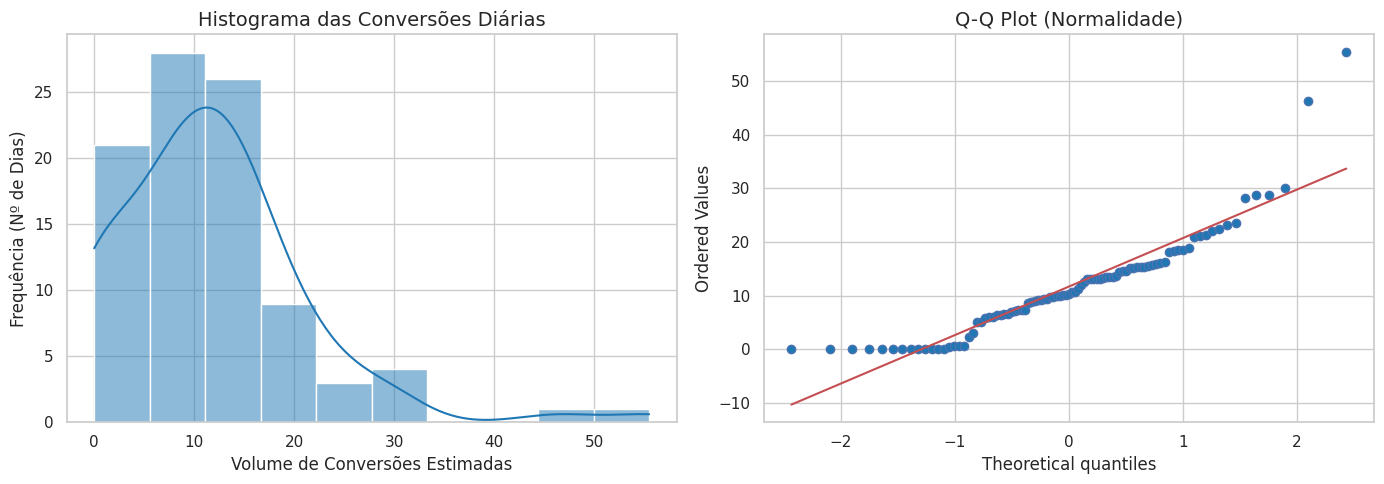


--- Teste de Normalidade de Shapiro-Wilk ---
Estatística de Teste: 0.8736
P-Valor: 0.0000

❌ RESULTADO: Rejeitamos H0. Os dados NÃO SEGUEM uma distribuição Normal.
💡 Isso significa que o seu tráfego/conversão é assimétrico (tem dias de picos fortes ou vales bruscos).


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# 1. Recriar a base diária rapidinho para garantir que o código rode liso
df_ads = df[df['sessionSourceMedium'] == 'google / cpc'].copy()
df_ads['date'] = pd.to_datetime(df_ads['date'], format='%Y%m%d')

df_diario = df_ads.groupby(['date', 'sessionGoogleAdsAdGroupName']).agg(
    sessoes=('sessions', 'sum'),
    duracao_media=('averageSessionDuration', 'mean')
).reset_index()

def calcular_conversao(linha):
    t, s = linha['duracao_media'], linha['sessoes']
    if t <= 150: return s * 0.02
    elif t <= 250: return s * 0.10
    else: return s * 0.50

df_diario['conversoes_estimadas'] = df_diario.apply(calcular_conversao, axis=1)
tendencia_diaria = df_diario.groupby('date')['conversoes_estimadas'].sum().reset_index()

# Nossa variável que vai para o "banco dos réus"
dados_para_teste = tendencia_diaria['conversoes_estimadas']

# 2. Configurar os gráficos (Visual da Normalidade)
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Histograma + Curva de Densidade
sns.histplot(dados_para_teste, kde=True, ax=ax[0], color='#1f77b4', bins=10)
ax[0].set_title('Histograma das Conversões Diárias', fontsize=14)
ax[0].set_xlabel('Volume de Conversões Estimadas', fontsize=12)
ax[0].set_ylabel('Frequência (Nº de Dias)', fontsize=12)

# Gráfico 2: Q-Q Plot (Quantil-Quantil)
stats.probplot(dados_para_teste, dist="norm", plot=ax[1])
ax[1].set_title('Q-Q Plot (Normalidade)', fontsize=14)
ax[1].get_lines()[0].set_markerfacecolor('#1f77b4') # Cor dos pontinhos

plt.tight_layout()
plt.show()

# 3. Teste Estatístico (Shapiro-Wilk)
stat, p_valor = stats.shapiro(dados_para_teste)

print("\n--- Teste de Normalidade de Shapiro-Wilk ---")
print(f"Estatística de Teste: {stat:.4f}")
print(f"P-Valor: {p_valor:.4f}\n")

if p_valor > 0.05:
    print("✅ RESULTADO: Aceitamos H0. Os dados SEGUEM uma distribuição Normal (Gaussiana).")
    print("💡 Isso significa que a variação diária é equilibrada ao redor da média.")
else:
    print("❌ RESULTADO: Rejeitamos H0. Os dados NÃO SEGUEM uma distribuição Normal.")
    print("💡 Isso significa que o seu tráfego/conversão é assimétrico (tem dias de picos fortes ou vales bruscos).")